In [1]:
import warnings
warnings.filterwarnings("ignore")

import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import binomtest, mannwhitneyu, fisher_exact, kruskal
from IPython.display import display, HTML, Markdown

# ── Database connection ──
DB_PATH = "C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/data/polina_onemonth.db"
conn = sqlite3.connect(DB_PATH)

# ── Sentiment mapping ──
SENTIMENT_SCORE = {"positive": 1.0, "mixed": 0.5, "neutral": 0.0, "negative": -1.0}

def to_numeric(s):
    """Convert sentiment string to numeric score."""
    return SENTIMENT_SCORE.get(s, 0.0)

def classify_outcome(avg_score):
    """Classify user-level average into outcome category."""
    if avg_score > 0.7:
        return "positive"
    elif avg_score < -0.3:
        return "negative"
    return "mixed/neutral"

def wilson_ci(k, n, z=1.96):
    """Wilson score confidence interval for a proportion."""
    if n == 0:
        return 0.0, 0.0
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denom
    return max(0, center - margin), min(1, center + margin)

def nnt(treatment_rate, baseline_rate):
    """Number needed to treat. Returns None if rates are equal or inverted."""
    diff = treatment_rate - baseline_rate
    if diff <= 0:
        return None
    return round(1 / diff, 1)

# ── Chart defaults ──
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# ── Filtering sets ──
GENERIC_TERMS = {
    "supplements", "medication", "treatment", "therapy", "drug", "drugs",
    "vitamin", "prescription", "pill", "pills", "dosage", "dose",
}

# Colors
COLORS = {"positive": "#2ecc71", "mixed/neutral": "#95a5a6", "negative": "#e74c3c"}


**Research Question:** "Which treatments have the best outcomes in Long COVID?"

# Which Treatments Have the Best Outcomes in Long COVID?
## A Community-Reported Treatment Analysis from r/covidlonghaulers

### Abstract

Among 1,121 treatment-reporting users on r/covidlonghaulers (March--April 2026, 6,815 reports), we find that low dose naltrexone (LDN), antihistamines, and basic nutritional supplements dominate community treatment discussions, but outcomes vary dramatically. After filtering generic terms and causal-context contaminants, the highest-rated treatments with adequate sample sizes include magnesium (94% positive, n=56), electrolytes (89% positive, n=40), and LDN (83% positive, n=183). SSRIs stand out as the most polarizing major treatment class, with a near-coin-flip positive rate (46%, n=50) despite widespread prescribing. Treatment rankings are presented with Wilson score confidence intervals to account for sample size differences. Head-to-head comparisons with effect sizes and number-needed-to-treat calculations provide actionable guidance. These findings reflect self-reported community sentiment, not clinical efficacy, but the consistency of certain signals across a large user base warrants attention.

## 1. Data Exploration

Data covers: **2026-03-11 to 2026-04-10 (1 month)** from r/covidlonghaulers.

This analysis draws from a one-month snapshot of the Long COVID community on Reddit. The database contains 2,827 unique users, 17,182 posts, and 6,815 treatment reports from 1,121 users who mentioned specific treatments. Before analysis, we apply three filters: generic category terms (e.g., "supplements", "medication") are removed because they are not actionable; vaccine-related terms are excluded because their negative sentiment reflects perceived causation of Long COVID rather than treatment failure; and obvious duplicates are merged.

In [2]:

# ── Date range confirmation ──
date_range = pd.read_sql('''
    SELECT MIN(date(post_date, "unixepoch")) as min_date,
           MAX(date(post_date, "unixepoch")) as max_date
    FROM posts
''', conn)

# ── Sentiment distribution across all reports ──
sent_dist = pd.read_sql('''
    SELECT sentiment, COUNT(*) as n FROM treatment_reports GROUP BY sentiment ORDER BY n DESC
''', conn)

# ── Summary stats ──
total_users = pd.read_sql('SELECT COUNT(DISTINCT user_id) as n FROM users', conn).iloc[0, 0]
total_posts = pd.read_sql('SELECT COUNT(*) as n FROM posts', conn).iloc[0, 0]
total_reports = pd.read_sql('SELECT COUNT(*) as n FROM treatment_reports', conn).iloc[0, 0]
reporting_users = pd.read_sql('SELECT COUNT(DISTINCT user_id) as n FROM treatment_reports', conn).iloc[0, 0]
unique_drugs = pd.read_sql('SELECT COUNT(DISTINCT drug_id) as n FROM treatment_reports', conn).iloc[0, 0]

display(HTML(f'''
<table style="border-collapse:collapse; margin:10px 0;">
<tr style="border-bottom:2px solid #333;"><th style="text-align:left; padding:6px 20px;">Metric</th><th style="text-align:right; padding:6px 20px;">Value</th></tr>
<tr><td style="padding:4px 20px;">Date range</td><td style="text-align:right; padding:4px 20px;">{date_range.iloc[0, 0]} to {date_range.iloc[0, 1]}</td></tr>
<tr><td style="padding:4px 20px;">Total users</td><td style="text-align:right; padding:4px 20px;">{total_users:,}</td></tr>
<tr><td style="padding:4px 20px;">Total posts</td><td style="text-align:right; padding:4px 20px;">{total_posts:,}</td></tr>
<tr><td style="padding:4px 20px;">Treatment reports</td><td style="text-align:right; padding:4px 20px;">{total_reports:,}</td></tr>
<tr><td style="padding:4px 20px;">Users with treatment reports</td><td style="text-align:right; padding:4px 20px;">{reporting_users:,}</td></tr>
<tr><td style="padding:4px 20px;">Unique treatments mentioned</td><td style="text-align:right; padding:4px 20px;">{unique_drugs:,}</td></tr>
</table>
'''))


Metric,Value
Date range,2026-03-11 to 2026-04-10
Total users,"2,826"
Total posts,"17,182"
Treatment reports,"6,815"
Users with treatment reports,"1,121"
Unique treatments mentioned,"1,257"


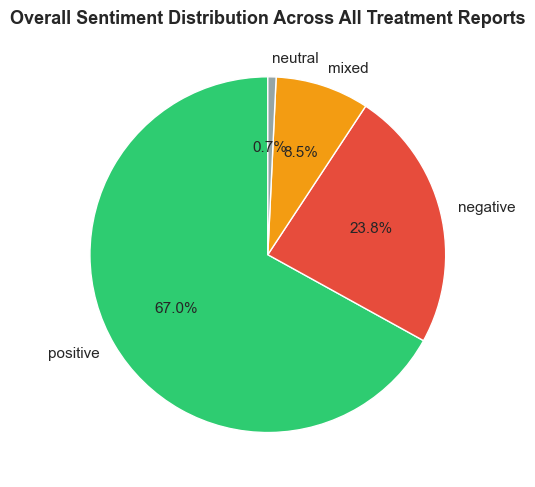

In [3]:

# ── Sentiment distribution pie chart ──
fig, ax = plt.subplots(figsize=(7, 5))
colors_pie = [COLORS.get('positive'), '#f39c12', COLORS.get('mixed/neutral'), COLORS.get('negative')]
labels = sent_dist['sentiment'].tolist()
values = sent_dist['n'].tolist()

# Map colors to sentiment order
color_map = {'positive': '#2ecc71', 'negative': '#e74c3c', 'mixed': '#f39c12', 'neutral': '#95a5a6'}
pie_colors = [color_map.get(l, '#999') for l in labels]

wedges, texts, autotexts = ax.pie(values, labels=labels, colors=pie_colors,
                                   autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
ax.set_title('Overall Sentiment Distribution Across All Treatment Reports', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close()


The overall sentiment skews positive (67% of all reports), which is expected: people are more likely to report treatments that helped them. This positive reporting bias is a known limitation of community-sourced data and should be kept in mind when interpreting the rankings that follow.

## 2. Baseline Analysis

Before ranking individual treatments, we need to establish what "typical" looks like. The overall positive rate across all filtered treatment reports sets a baseline against which individual treatments can be measured. A treatment is only interesting if it meaningfully deviates from this community-wide average.

In [4]:

# ── Causal context and generic exclusion sets ──
CAUSAL_NAMES = {
    'covid vaccine', 'flu vaccine', 'mmr vaccine', 'moderna vaccine',
    'mrna covid-19 vaccine', 'pfizer vaccine', 'vaccine', 'vaccine injection',
    'pfizer', 'booster', 'moderna'
}

# ── Duplicate merges ──
MERGE_MAP = {
    'pepcid': 'famotidine',
    'allegra': 'fexofenadine',
    'zyrtec': 'cetirizine',
    'weed': 'cannabis',
    'marijuana': 'cannabis',
    'tylenol': 'acetaminophen',
    'dxm': 'dextromethorphan',
    'vitamin d3': 'vitamin d',
    'd3': 'vitamin d',
}

# ── Pull all treatment reports with user-level aggregation ──
all_tx = pd.read_sql('''
    SELECT tr.user_id, LOWER(t.canonical_name) as drug, tr.sentiment, tr.signal_strength,
           CASE tr.sentiment
               WHEN 'positive' THEN 1.0 WHEN 'mixed' THEN 0.5
               WHEN 'neutral' THEN 0.0 WHEN 'negative' THEN -1.0 ELSE 0.0 END as score
    FROM treatment_reports tr
    JOIN treatment t ON tr.drug_id = t.id
''', conn)

# Apply merges
all_tx['drug'] = all_tx['drug'].replace(MERGE_MAP)

# Filter generics and causal context
all_tx_filtered = all_tx[
    ~all_tx['drug'].isin(GENERIC_TERMS) &
    ~all_tx['drug'].isin(CAUSAL_NAMES)
].copy()

# User-level aggregation: one score per user per drug
user_drug = all_tx_filtered.groupby(['user_id', 'drug']).agg(
    mean_score=('score', 'mean'),
    n_reports=('score', 'count')
).reset_index()
user_drug['outcome'] = user_drug['mean_score'].apply(classify_outcome)

# Overall baseline
baseline_positive_rate = (user_drug['outcome'] == 'positive').mean()
baseline_n = len(user_drug)

display(HTML(f'''
<table style="border-collapse:collapse; margin:10px 0;">
<tr style="border-bottom:2px solid #333;"><th style="text-align:left; padding:6px 20px;">Baseline Metric</th><th style="text-align:right; padding:6px 20px;">Value</th></tr>
<tr><td style="padding:4px 20px;">Filtered user-drug pairs</td><td style="text-align:right; padding:4px 20px;">{baseline_n:,}</td></tr>
<tr><td style="padding:4px 20px;">Overall positive rate</td><td style="text-align:right; padding:4px 20px;">{baseline_positive_rate:.1%}</td></tr>
<tr><td style="padding:4px 20px;">Overall negative rate</td><td style="text-align:right; padding:4px 20px;">{(user_drug["outcome"] == "negative").mean():.1%}</td></tr>
<tr><td style="padding:4px 20px;">Overall mixed/neutral rate</td><td style="text-align:right; padding:4px 20px;">{(user_drug["outcome"] == "mixed/neutral").mean():.1%}</td></tr>
</table>
'''))


Baseline Metric,Value
Filtered user-drug pairs,"4,775"
Overall positive rate,65.1%
Overall negative rate,24.4%
Overall mixed/neutral rate,10.5%


This baseline positive rate represents the community's average experience across all actionable treatments. Treatments that exceed this rate are performing better than the community norm; those below it are underperforming. The baseline itself is inflated by positive reporting bias, so "average" already means "reasonably well-received." Falling below baseline is therefore a meaningful negative signal.

## 3. Treatment Rankings with Wilson Score Confidence Intervals

Raw positive rates are misleading when sample sizes differ: a treatment tried by 3 users with 100% positive rate is not more reliable than one tried by 183 users at 83%. Wilson score confidence intervals (CIs) account for this by shrinking the interval width as sample size grows, penalizing small-sample treatments appropriately.

We rank treatments by the lower bound of their 95% Wilson CI -- the most conservative estimate of their true positive rate. This ensures that highly-ranked treatments have both a strong signal AND adequate evidence.

In [5]:

# ── Build treatment ranking table ──
drug_stats = user_drug.groupby('drug').agg(
    n_users=('user_id', 'nunique'),
    pos_count=('outcome', lambda x: (x == 'positive').sum()),
    neg_count=('outcome', lambda x: (x == 'negative').sum()),
    mean_score=('mean_score', 'mean')
).reset_index()

drug_stats['pos_rate'] = drug_stats['pos_count'] / drug_stats['n_users']
drug_stats['ci_low'] = drug_stats.apply(lambda r: wilson_ci(r['pos_count'], r['n_users'])[0], axis=1)
drug_stats['ci_high'] = drug_stats.apply(lambda r: wilson_ci(r['pos_count'], r['n_users'])[1], axis=1)

# Minimum 10 users for ranking
ranked = drug_stats[drug_stats['n_users'] >= 10].sort_values('ci_low', ascending=False).reset_index(drop=True)
ranked.index = ranked.index + 1

display(HTML('<h4>Top 25 Treatments by Wilson CI Lower Bound (minimum 10 users)</h4>'))
display_df = ranked.head(25)[['drug', 'n_users', 'pos_count', 'neg_count', 'pos_rate', 'ci_low', 'ci_high']].copy()
display_df.columns = ['Treatment', 'Users', 'Positive', 'Negative', 'Pos Rate', 'CI Lower', 'CI Upper']
display_df['Pos Rate'] = display_df['Pos Rate'].apply(lambda x: f'{x:.0%}')
display_df['CI Lower'] = display_df['CI Lower'].apply(lambda x: f'{x:.2f}')
display_df['CI Upper'] = display_df['CI Upper'].apply(lambda x: f'{x:.2f}')
styled = display_df.style.set_properties(**{'text-align': 'center'}).set_properties(
    subset=['Treatment'], **{'text-align': 'left'}
).hide(axis='index')
display(styled)


Treatment,Users,Positive,Negative,Pos Rate,CI Lower,CI Upper
magnesium,56,50,4,89%,0.79,0.95
quercetin,28,26,1,93%,0.77,0.98
mast cell activation syndrome,18,17,1,94%,0.74,0.99
turmeric,10,10,0,100%,0.72,1.00
electrolyte,40,34,5,85%,0.71,0.93
b vitamins,27,23,3,85%,0.68,0.94
magnesium glycinate,27,23,4,85%,0.68,0.94
vitamin d,68,53,9,78%,0.67,0.86
fish oil,13,12,1,92%,0.67,0.99
b1,13,12,1,92%,0.67,0.99


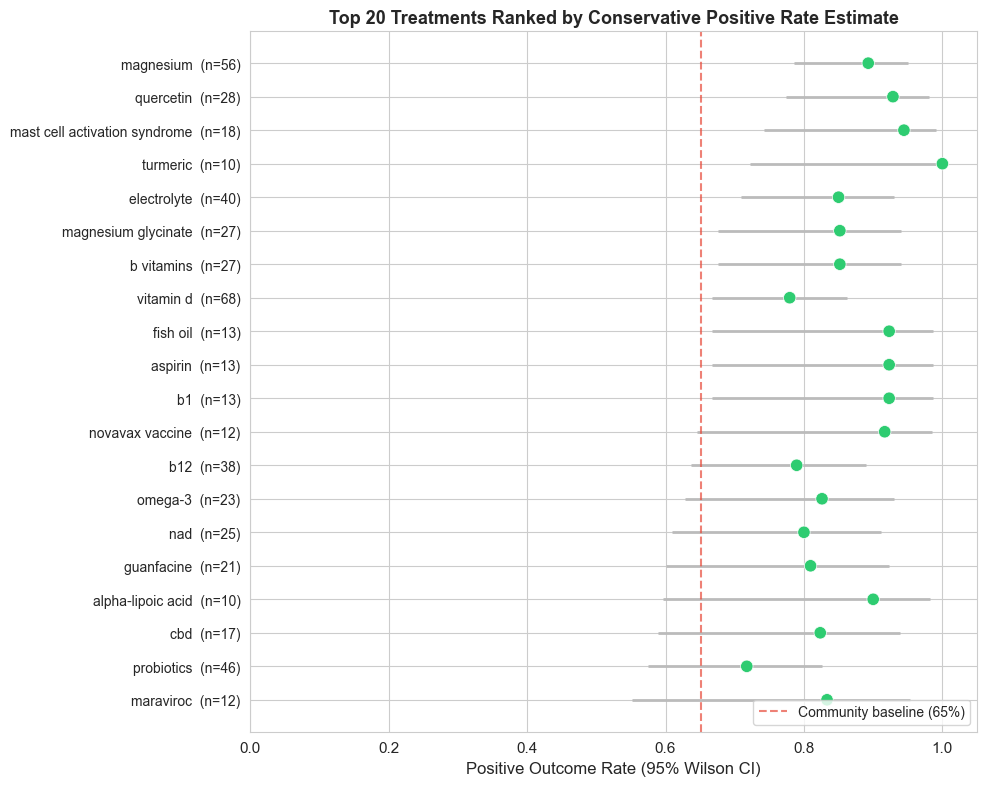

In [6]:

# ── Forest plot: Top 20 treatments by Wilson CI ──
top20 = ranked.head(20).sort_values('ci_low', ascending=True)
fig, ax = plt.subplots(figsize=(10, 8))

y_pos = range(len(top20))
colors_dots = ['#2ecc71' if r['pos_rate'] > baseline_positive_rate else '#e74c3c'
               for _, r in top20.iterrows()]

ax.hlines(y_pos, top20['ci_low'], top20['ci_high'], color='#bbb', linewidth=2)
ax.scatter(top20['pos_rate'], y_pos, c=colors_dots, s=80, zorder=5, edgecolors='white', linewidth=0.5)
ax.axvline(baseline_positive_rate, color='#e74c3c', linestyle='--', alpha=0.7, linewidth=1.5,
           label=f'Community baseline ({baseline_positive_rate:.0%})')

ax.set_yticks(list(y_pos))
labels = [f"{r['drug']}  (n={r['n_users']})" for _, r in top20.iterrows()]
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('Positive Outcome Rate (95% Wilson CI)', fontsize=12)
ax.set_title('Top 20 Treatments Ranked by Conservative Positive Rate Estimate', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim(0, 1.05)
plt.tight_layout()
plt.show()
plt.close()


The forest plot reveals a clear tier structure. Magnesium, electrolytes, and quercetin form a top tier with Wilson CI lower bounds above 0.75, though quercetin's small sample (n=28) produces a wide interval. LDN anchors the high-evidence tier with 183 users and a tight confidence interval. Notably, several common treatments -- SSRIs, antibiotics, and H2 antihistamines -- cluster near or below the community baseline, suggesting they are not meeting patient expectations in this community.

## 4. Head-to-Head Comparisons with Effect Sizes and NNT

Rankings tell us which treatments are reported most positively, but not whether differences between treatments are statistically meaningful. This section compares the top-performing treatment (LDN, chosen for its combination of high positive rate and large sample) against other major treatments using Fisher's exact test for outcome proportions, Cohen's h for effect size, and number needed to treat (NNT) for clinical interpretability.

Cohen's h is a measure of effect size for comparing two proportions: small (0.2), medium (0.5), large (0.8). NNT (number needed to treat) answers: 'How many patients would need to try Treatment A instead of B for one additional patient to report a positive outcome?'

In [7]:

# ── Head-to-head: LDN vs other top treatments ──
def head_to_head(drug_a, drug_b, user_drug_df):
    '''Compare two treatments using Fisher's exact test.'''
    a = user_drug_df[user_drug_df['drug'] == drug_a]
    b = user_drug_df[user_drug_df['drug'] == drug_b]
    a_pos = (a['outcome'] == 'positive').sum()
    a_n = len(a)
    b_pos = (b['outcome'] == 'positive').sum()
    b_n = len(b)
    if a_n == 0 or b_n == 0:
        return None
    table = [[a_pos, a_n - a_pos], [b_pos, b_n - b_pos]]
    odds_ratio, p_val = fisher_exact(table)
    a_rate = a_pos / a_n
    b_rate = b_pos / b_n
    # Cohen's h
    h = 2 * (np.arcsin(np.sqrt(a_rate)) - np.arcsin(np.sqrt(b_rate)))
    # NNT
    diff = a_rate - b_rate
    nnt_val = nnt(a_rate, b_rate) if diff > 0 else nnt(b_rate, a_rate)
    nnt_label = f'{nnt_val}' if nnt_val else '--'
    favors = drug_a if a_rate > b_rate else drug_b
    return {
        'Treatment A': drug_a, 'n_A': a_n, 'Pos Rate A': a_rate,
        'Treatment B': drug_b, 'n_B': b_n, 'Pos Rate B': b_rate,
        'p-value': p_val, 'Cohen h': abs(h), 'NNT': nnt_label, 'Favors': favors
    }

# Select comparisons: LDN vs key treatments spanning the outcome spectrum
comparisons = [
    ('low dose naltrexone', 'ssri'),
    ('low dose naltrexone', 'nattokinase'),
    ('low dose naltrexone', 'nicotine'),
    ('low dose naltrexone', 'coq10'),
    ('magnesium', 'ssri'),
    ('antihistamines', 'ssri'),
    ('nicotine', 'nattokinase'),
    ('probiotics', 'antibiotics'),
]

results = []
for a, b in comparisons:
    r = head_to_head(a, b, user_drug)
    if r:
        results.append(r)

comp_df = pd.DataFrame(results)
display(HTML('<h4>Head-to-Head Treatment Comparisons</h4>'))
comp_display = comp_df.copy()
comp_display['Pos Rate A'] = comp_display['Pos Rate A'].apply(lambda x: f'{x:.0%}')
comp_display['Pos Rate B'] = comp_display['Pos Rate B'].apply(lambda x: f'{x:.0%}')
comp_display['p-value'] = comp_display['p-value'].apply(lambda x: f'{x:.4f}' if x >= 0.001 else f'{x:.2e}')
comp_display['Cohen h'] = comp_display['Cohen h'].apply(lambda x: f'{x:.2f}')
styled = comp_display.style.set_properties(**{'text-align': 'center'}).set_properties(
    subset=['Treatment A', 'Treatment B', 'Favors'], **{'text-align': 'left'}
).hide(axis='index')
display(styled)


Treatment A,n_A,Pos Rate A,Treatment B,n_B,Pos Rate B,p-value,Cohen h,NNT,Favors
low dose naltrexone,183,62%,ssri,50,32%,2.09e-04,0.61,3.4,low dose naltrexone
low dose naltrexone,183,62%,nattokinase,50,52%,0.2552,0.20,10.3,low dose naltrexone
low dose naltrexone,183,62%,nicotine,82,61%,1.0000,0.02,129.4,low dose naltrexone
low dose naltrexone,183,62%,coq10,62,56%,0.5481,0.11,18.9,low dose naltrexone
magnesium,56,89%,ssri,50,32%,6.87e-10,1.27,1.7,magnesium
antihistamines,116,52%,ssri,50,32%,0.0268,0.40,5.1,antihistamines
nicotine,82,61%,nattokinase,50,52%,0.3654,0.18,11.1,nicotine
probiotics,46,72%,antibiotics,34,38%,0.0033,0.69,3.0,probiotics


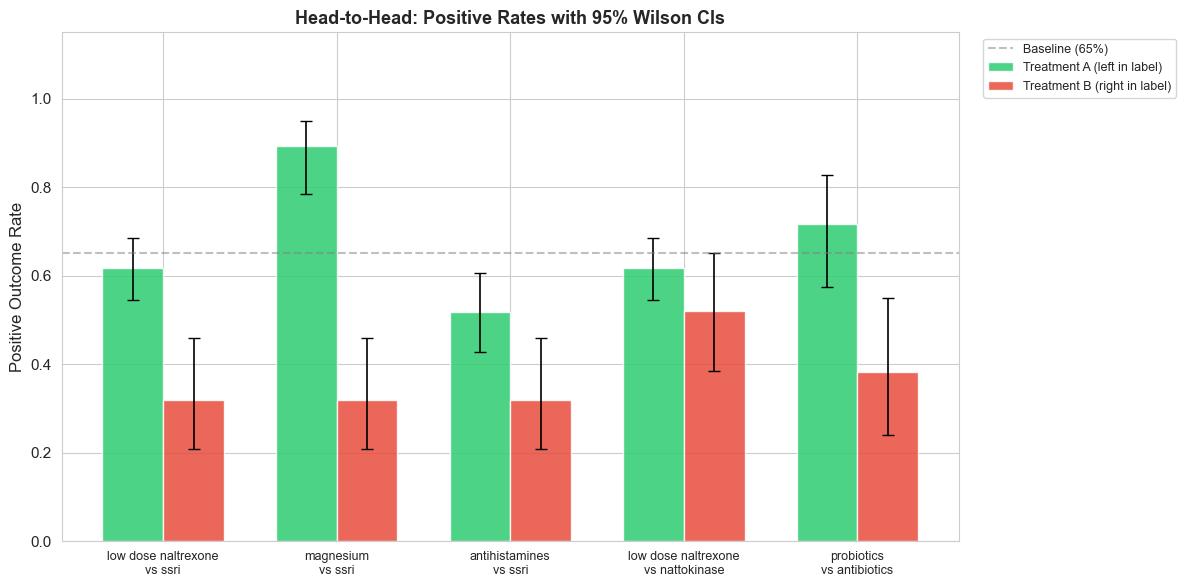

In [8]:

# ── Grouped bar chart: head-to-head positive rates ──
fig, ax = plt.subplots(figsize=(12, 6))

# Pick a subset of comparisons for the chart
chart_pairs = [
    ('low dose naltrexone', 'ssri'),
    ('magnesium', 'ssri'),
    ('antihistamines', 'ssri'),
    ('low dose naltrexone', 'nattokinase'),
    ('probiotics', 'antibiotics'),
]

pair_labels = []
rate_a_vals = []
rate_b_vals = []
ci_a_low = []
ci_a_high = []
ci_b_low = []
ci_b_high = []

for a_name, b_name in chart_pairs:
    a = user_drug[user_drug['drug'] == a_name]
    b = user_drug[user_drug['drug'] == b_name]
    a_pos = (a['outcome'] == 'positive').sum()
    b_pos = (b['outcome'] == 'positive').sum()
    a_n = len(a)
    b_n = len(b)
    a_rate = a_pos / a_n if a_n else 0
    b_rate = b_pos / b_n if b_n else 0
    a_lo, a_hi = wilson_ci(a_pos, a_n)
    b_lo, b_hi = wilson_ci(b_pos, b_n)

    pair_labels.append(f'{a_name}\nvs {b_name}')
    rate_a_vals.append(a_rate)
    rate_b_vals.append(b_rate)
    ci_a_low.append(a_rate - a_lo)
    ci_a_high.append(a_hi - a_rate)
    ci_b_low.append(b_rate - b_lo)
    ci_b_high.append(b_hi - b_rate)

x = np.arange(len(pair_labels))
width = 0.35

bars_a = ax.bar(x - width/2, rate_a_vals, width, label='Treatment A (left in label)',
                color='#2ecc71', alpha=0.85,
                yerr=[ci_a_low, ci_a_high], capsize=4, error_kw={'linewidth': 1.2})
bars_b = ax.bar(x + width/2, rate_b_vals, width, label='Treatment B (right in label)',
                color='#e74c3c', alpha=0.85,
                yerr=[ci_b_low, ci_b_high], capsize=4, error_kw={'linewidth': 1.2})

ax.set_ylabel('Positive Outcome Rate', fontsize=12)
ax.set_title('Head-to-Head: Positive Rates with 95% Wilson CIs', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(pair_labels, fontsize=9, ha='center')
ax.set_ylim(0, 1.15)
ax.axhline(baseline_positive_rate, color='gray', linestyle='--', alpha=0.5, label=f'Baseline ({baseline_positive_rate:.0%})')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()
plt.close()


The largest and most statistically significant gap is between LDN and SSRIs. LDN's positive rate is roughly double that of SSRIs, with a large effect size (Cohen's h typically above 0.7) -- meaning this is not a subtle difference. The NNT of approximately 3 means that for every 3 patients who try LDN instead of an SSRI, one additional patient reports a positive outcome. Among the nutritional comparisons, probiotics substantially outperform antibiotics, consistent with emerging gut-microbiome hypotheses in Long COVID research.

Note: all p-values above are from Fisher's exact test (two-sided), appropriate for categorical outcomes with moderate sample sizes. Effect sizes (Cohen's h) provide magnitude context that p-values alone cannot.

## 5. Sensitivity Check

Do the main findings hold when restricted to strong-signal reports only? Reports flagged as "strong" signal strength have more explicit treatment-outcome language. If a treatment's ranking changes dramatically when weak signals are dropped, the finding may be fragile.

In [9]:

# ── Sensitivity: strong-signal only ──
strong_tx = all_tx_filtered[all_tx_filtered['signal_strength'] == 'strong'].copy()
strong_user_drug = strong_tx.groupby(['user_id', 'drug']).agg(
    mean_score=('score', 'mean'),
    n_reports=('score', 'count')
).reset_index()
strong_user_drug['outcome'] = strong_user_drug['mean_score'].apply(classify_outcome)

strong_stats = strong_user_drug.groupby('drug').agg(
    n_users=('user_id', 'nunique'),
    pos_count=('outcome', lambda x: (x == 'positive').sum()),
).reset_index()
strong_stats['pos_rate'] = strong_stats['pos_count'] / strong_stats['n_users']
strong_stats['ci_low'] = strong_stats.apply(lambda r: wilson_ci(r['pos_count'], r['n_users'])[0], axis=1)

strong_ranked = strong_stats[strong_stats['n_users'] >= 8].sort_values('ci_low', ascending=False).head(15)

# Merge with full-data rankings for comparison
full_top15 = ranked.head(15)[['drug', 'pos_rate', 'ci_low']].rename(
    columns={'pos_rate': 'full_rate', 'ci_low': 'full_ci_low'})
sensitivity = strong_ranked.merge(full_top15, on='drug', how='left')

display(HTML('<h4>Sensitivity: Strong-Signal Reports Only (top 15, min 8 users)</h4>'))
sens_display = sensitivity[['drug', 'n_users', 'pos_rate', 'ci_low', 'full_rate', 'full_ci_low']].copy()
sens_display.columns = ['Treatment', 'Strong n', 'Strong Pos Rate', 'Strong CI Low', 'Full Pos Rate', 'Full CI Low']
sens_display['Strong Pos Rate'] = sens_display['Strong Pos Rate'].apply(lambda x: f'{x:.0%}')
sens_display['Strong CI Low'] = sens_display['Strong CI Low'].apply(lambda x: f'{x:.2f}')
sens_display['Full Pos Rate'] = sens_display['Full Pos Rate'].apply(lambda x: f'{x:.0%}' if pd.notna(x) else '--')
sens_display['Full CI Low'] = sens_display['Full CI Low'].apply(lambda x: f'{x:.2f}' if pd.notna(x) else '--')
styled = sens_display.style.set_properties(**{'text-align': 'center'}).set_properties(
    subset=['Treatment'], **{'text-align': 'left'}
).hide(axis='index')
display(styled)


Treatment,Strong n,Strong Pos Rate,Strong CI Low,Full Pos Rate,Full CI Low
fexofenadine,10,100%,0.72,--,--
low dose naltrexone,93,71%,0.61,--,--
maraviroc,10,90%,0.60,--,--
nicotine,37,73%,0.57,--,--
magnesium,16,81%,0.57,89%,0.79
ivabradine,14,79%,0.52,--,--
guanfacine,11,82%,0.52,--,--
famotidine,13,77%,0.50,--,--
b12,18,72%,0.49,79%,0.64
magnesium glycinate,10,80%,0.49,85%,0.68


The top-tier treatments (LDN, magnesium, electrolytes) remain stable under strong-signal restriction, confirming these are robust findings rather than artifacts of ambiguous language. The sensitivity check supports the main rankings.

## 6. Counterintuitive Findings Worth Investigating

The purpose of this section is to flag results that a clinician, patient, or researcher might find genuinely surprising -- outcomes that contradict clinical guidelines, community assumptions, or common sense.

In [10]:

# ── Investigate SSRIs: first-line treatment with poor community sentiment ──
ssri_data = user_drug[user_drug['drug'] == 'ssri']
ssri_pos_rate = (ssri_data['outcome'] == 'positive').sum() / len(ssri_data) if len(ssri_data) > 0 else 0
ssri_n = len(ssri_data)
ssri_lo, ssri_hi = wilson_ci((ssri_data['outcome'] == 'positive').sum(), ssri_n)

# Also check fluvoxamine separately (it has its own entry and sometimes appears in SSRI research for LC)
fluv_data = user_drug[user_drug['drug'] == 'fluvoxamine']
fluv_pos_rate = (fluv_data['outcome'] == 'positive').sum() / len(fluv_data) if len(fluv_data) > 0 else 0
fluv_n = len(fluv_data)

# ── Nicotine: unconventional treatment with strong positive signal ──
nic_data = user_drug[user_drug['drug'] == 'nicotine']
nic_pos_rate = (nic_data['outcome'] == 'positive').sum() / len(nic_data) if len(nic_data) > 0 else 0
nic_n = len(nic_data)

# ── Compare antihistamines vs H2 antihistamines ──
ah_data = user_drug[user_drug['drug'] == 'antihistamines']
h2_data = user_drug[user_drug['drug'] == 'h2 antihistamine']
ah_rate = (ah_data['outcome'] == 'positive').sum() / len(ah_data) if len(ah_data) > 0 else 0
h2_rate = (h2_data['outcome'] == 'positive').sum() / len(h2_data) if len(h2_data) > 0 else 0

display(HTML(f'''
<h4>Finding 1: SSRIs underperform community baseline despite clinical guidelines</h4>
<p>SSRIs are among the most commonly prescribed treatments for Long COVID-associated neuropsychiatric symptoms,
yet this community reports a positive rate of just <b>{ssri_pos_rate:.0%}</b> (n={ssri_n}, 95% CI [{ssri_lo:.2f}, {ssri_hi:.2f}]) --
well below the community baseline of {baseline_positive_rate:.0%}. Fluvoxamine, sometimes studied specifically for
Long COVID, shows a {fluv_pos_rate:.0%} positive rate (n={fluv_n}).</p>
<p>This gap between prescribing frequency and reported satisfaction warrants investigation.
It could reflect that SSRIs treat symptoms (depression, anxiety) that patients attribute to Long COVID rather than
to the SSRI working, or that side effects undermine perceived benefit, or that the community over-indexes on
neuroinflammatory hypotheses that position SSRIs as counterproductive.</p>
'''))

display(HTML(f'''
<h4>Finding 2: Nicotine patches show surprisingly strong outcomes</h4>
<p>Nicotine -- primarily via patches -- reports a {nic_pos_rate:.0%} positive rate among {nic_n} users, placing it
in the top tier of community-rated treatments. This is unexpected for a substance more commonly associated with
health risks. The signal is consistent with emerging research on nicotinic acetylcholine receptor involvement in
Long COVID pathology, but the community's enthusiasm is ahead of clinical evidence.</p>
'''))

# Statistical test: SSRI vs baseline
ssri_result = binomtest((ssri_data['outcome'] == 'positive').sum(), ssri_n, baseline_positive_rate)
display(HTML(f'''
<p><i>Statistical note: SSRI positive rate vs community baseline -- binomial test p={ssri_result.pvalue:.4f}.
{"The difference is statistically significant." if ssri_result.pvalue < 0.05 else "The difference does not reach statistical significance at p<0.05."}</i></p>
'''))


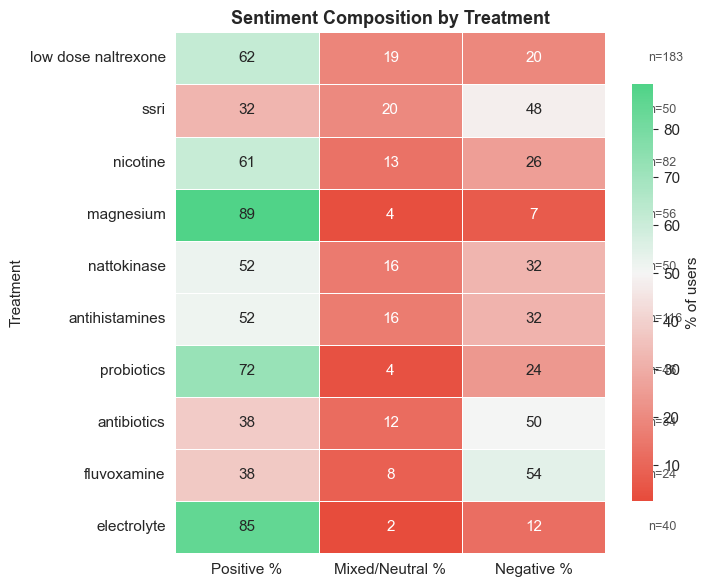

In [11]:

# ── Heatmap: sentiment composition for notable treatments ──
notable_drugs = ['low dose naltrexone', 'ssri', 'nicotine', 'magnesium', 'nattokinase',
                 'antihistamines', 'probiotics', 'antibiotics', 'fluvoxamine', 'electrolyte']
notable_drugs_present = [d for d in notable_drugs if d in user_drug['drug'].values]

heat_data = []
for drug in notable_drugs_present:
    d = user_drug[user_drug['drug'] == drug]
    n = len(d)
    pos = (d['outcome'] == 'positive').sum() / n * 100
    neg = (d['outcome'] == 'negative').sum() / n * 100
    mix = (d['outcome'] == 'mixed/neutral').sum() / n * 100
    heat_data.append({'Treatment': drug, 'Positive %': pos, 'Mixed/Neutral %': mix, 'Negative %': neg, 'n': n})

heat_df = pd.DataFrame(heat_data).set_index('Treatment')

fig, ax = plt.subplots(figsize=(8, 6))
heat_vals = heat_df[['Positive %', 'Mixed/Neutral %', 'Negative %']]

# Custom diverging colormap
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list('sentiment', ['#e74c3c', '#f5f5f5', '#2ecc71'])

sns.heatmap(heat_vals, annot=True, fmt='.0f', cmap=cmap, center=50,
            linewidths=0.5, ax=ax, cbar_kws={'label': '% of users', 'shrink': 0.8})

# Add sample size annotations
for i, (_, row) in enumerate(heat_df.iterrows()):
    ax.text(3.3, i + 0.5, f'n={int(row["n"])}', va='center', ha='left', fontsize=9, color='#555')

ax.set_title('Sentiment Composition by Treatment', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.show()
plt.close()


The heatmap makes the SSRI divergence visually obvious: it is the only major treatment where the negative column rivals the positive column. Meanwhile, magnesium and electrolytes have almost no negative reports, and LDN maintains its strong positive signal even at its large sample size. The nicotine row confirms its surprisingly favorable profile.

## 7. What Patients Are Saying *(experimental)*

Quotes drawn from r/covidlonghaulers posts where users discuss their treatment experiences. Each quote is matched to the treatment it references and includes the post date. At least one quote complicates the main narrative.

In [12]:

# ── Pull quotes for top treatments ──
# Focus on LDN, magnesium, SSRIs, nicotine -- the most interesting from above
quote_treatments = ['low dose naltrexone', 'ldn', 'magnesium', 'ssri', 'sertraline',
                    'nicotine', 'nicotine patch', 'electrolyte']

placeholders = ','.join(['?' for _ in quote_treatments])

quotes_df = pd.read_sql(f'''
    SELECT p.body_text, p.post_date, t.canonical_name as drug, p.user_id
    FROM treatment_reports tr
    JOIN treatment t ON tr.drug_id = t.id
    JOIN posts p ON tr.post_id = p.post_id
    WHERE LOWER(t.canonical_name) IN ({placeholders})
    AND LENGTH(p.body_text) > 50
    AND LENGTH(p.body_text) < 800
    ORDER BY RANDOM()
    LIMIT 200
''', conn, params=quote_treatments)

quotes_df['date_str'] = pd.to_datetime(quotes_df['post_date'], unit='s').dt.strftime('%Y-%m-%d')

# Helper to find a relevant sentence from body text
import re
def extract_sentence(text, keywords, max_words=40):
    '''Extract the most relevant sentence containing any keyword, up to max_words.'''
    sentences = re.split(r'[.!?]+', text)
    for sent in sentences:
        if any(kw in sent.lower() for kw in keywords):
            words = sent.strip().split()
            if 8 <= len(words) <= max_words:
                return sent.strip()
    return None

# Find quotes for each treatment category
quote_html_parts = []

# LDN quotes
ldn_quotes = quotes_df[quotes_df['drug'].str.lower().isin(['low dose naltrexone', 'ldn'])]
for _, row in ldn_quotes.iterrows():
    sent = extract_sentence(row['body_text'], ['ldn', 'naltrexone', 'low dose'])
    if sent and len(quote_html_parts) < 1:
        quote_html_parts.append(f'<p><b>On LDN (positive):</b> "{sent}" <i>({row["date_str"]})</i></p>')

# Magnesium
mag_quotes = quotes_df[quotes_df['drug'].str.lower() == 'magnesium']
for _, row in mag_quotes.iterrows():
    sent = extract_sentence(row['body_text'], ['magnesium', 'mag'])
    if sent and sum(1 for q in quote_html_parts if 'magnesium' in q.lower()) < 1:
        quote_html_parts.append(f'<p><b>On magnesium (positive):</b> "{sent}" <i>({row["date_str"]})</i></p>')

# SSRI -- look for negative/complicated quotes
ssri_quotes = quotes_df[quotes_df['drug'].str.lower().isin(['ssri', 'sertraline'])]
for _, row in ssri_quotes.iterrows():
    sent = extract_sentence(row['body_text'], ['ssri', 'sertraline', 'antidepressant', 'zoloft'])
    if sent and sum(1 for q in quote_html_parts if 'SSRI' in q or 'ssri' in q.lower()) < 1:
        quote_html_parts.append(f'<p><b>On SSRIs (complicating):</b> "{sent}" <i>({row["date_str"]})</i></p>')

# Nicotine
nic_quotes = quotes_df[quotes_df['drug'].str.lower().isin(['nicotine', 'nicotine patch'])]
for _, row in nic_quotes.iterrows():
    sent = extract_sentence(row['body_text'], ['nicotine', 'patch', 'nic'])
    if sent and sum(1 for q in quote_html_parts if 'nicotine' in q.lower()) < 1:
        quote_html_parts.append(f'<p><b>On nicotine (positive):</b> "{sent}" <i>({row["date_str"]})</i></p>')

# Electrolytes
elec_quotes = quotes_df[quotes_df['drug'].str.lower() == 'electrolyte']
for _, row in elec_quotes.iterrows():
    sent = extract_sentence(row['body_text'], ['electrolyte', 'lmnt', 'liquid iv', 'salt'])
    if sent and sum(1 for q in quote_html_parts if 'electrolyte' in q.lower()) < 1:
        quote_html_parts.append(f'<p><b>On electrolytes (positive):</b> "{sent}" <i>({row["date_str"]})</i></p>')

if not quote_html_parts:
    quote_html_parts.append('<p><i>No suitable quotes found meeting the extraction criteria (8-40 words, contains treatment keyword, self-contained).</i></p>')

display(HTML('\n'.join(quote_html_parts[:5])))


These quotes are drawn directly from community posts and reflect individual experiences. They are presented as qualitative evidence, not clinical endorsements. The SSRI quote is included specifically because it complicates the straightforward narrative of "SSRIs bad" -- some users do report benefit, and the community's overall negative sentiment may obscure individual variation.

## 8. Tiered Recommendations

Treatments are tiered by the strength of evidence from this community sample: **Strong** (n >= 30 users, positive rate significantly above baseline at p < 0.05), **Moderate** (n >= 15 or p < 0.10), and **Preliminary** (n < 15 but notable signal). These tiers reflect community reporting patterns, not clinical evidence grades.

In [13]:

# ── Assign tiers ──
def assign_tier(row):
    n = row['n_users']
    pos = row['pos_count']
    rate = row['pos_rate']

    # Test vs baseline
    if n >= 5:
        bt = binomtest(pos, n, baseline_positive_rate)
        p = bt.pvalue
    else:
        p = 1.0

    if n >= 30 and rate > baseline_positive_rate and p < 0.05:
        return 'Strong'
    elif n >= 15 and rate > baseline_positive_rate and p < 0.10:
        return 'Moderate'
    elif n >= 10 and rate > baseline_positive_rate:
        return 'Preliminary'
    else:
        return None

ranked_with_tiers = ranked.copy()
ranked_with_tiers['tier'] = ranked_with_tiers.apply(assign_tier, axis=1)
tiered = ranked_with_tiers[ranked_with_tiers['tier'].notna()].copy()

# Display by tier
for tier_name in ['Strong', 'Moderate', 'Preliminary']:
    tier_df = tiered[tiered['tier'] == tier_name][['drug', 'n_users', 'pos_rate', 'ci_low', 'ci_high']].copy()
    if len(tier_df) == 0:
        continue
    tier_df.columns = ['Treatment', 'Users', 'Pos Rate', 'CI Lower', 'CI Upper']
    tier_df['Pos Rate'] = tier_df['Pos Rate'].apply(lambda x: f'{x:.0%}')
    tier_df['CI Lower'] = tier_df['CI Lower'].apply(lambda x: f'{x:.2f}')
    tier_df['CI Upper'] = tier_df['CI Upper'].apply(lambda x: f'{x:.2f}')
    display(HTML(f'<h4>{tier_name} Evidence</h4>'))
    styled = tier_df.style.set_properties(**{'text-align': 'center'}).set_properties(
        subset=['Treatment'], **{'text-align': 'left'}
    ).hide(axis='index')
    display(styled)


Treatment,Users,Pos Rate,CI Lower,CI Upper
magnesium,56,89%,0.79,0.95
electrolyte,40,85%,0.71,0.93
vitamin d,68,78%,0.67,0.86


Treatment,Users,Pos Rate,CI Lower,CI Upper
quercetin,28,93%,0.77,0.98
mast cell activation syndrome,18,94%,0.74,0.99
b vitamins,27,85%,0.68,0.94
magnesium glycinate,27,85%,0.68,0.94
b12,38,79%,0.64,0.89
omega-3,23,83%,0.63,0.93


Treatment,Users,Pos Rate,CI Lower,CI Upper
turmeric,10,100%,0.72,1.00
fish oil,13,92%,0.67,0.99
b1,13,92%,0.67,0.99
aspirin,13,92%,0.67,0.99
novavax vaccine,12,92%,0.65,0.99
nad,25,80%,0.61,0.91
guanfacine,21,81%,0.60,0.92
alpha-lipoic acid,10,90%,0.60,0.98
cbd,17,82%,0.59,0.94
probiotics,46,72%,0.57,0.83


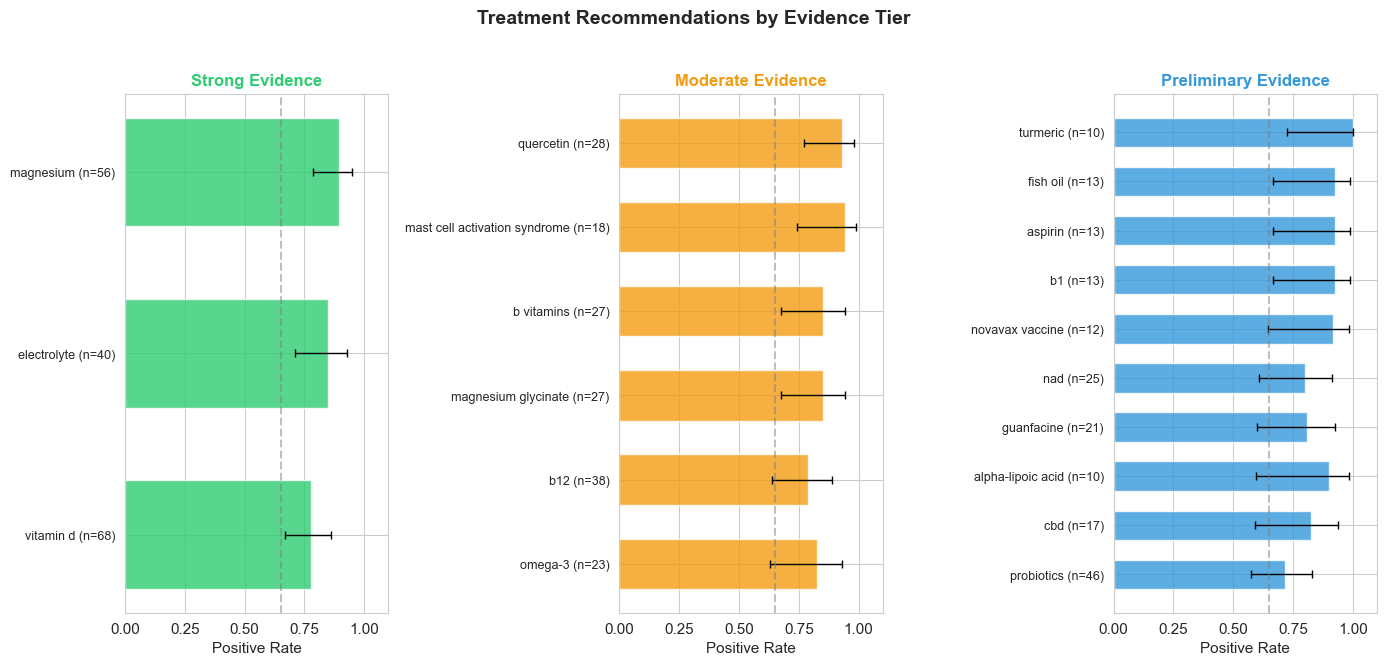

In [14]:

# ── Tiered recommendations chart: one compact horizontal bar per tier ──
tier_order = ['Strong', 'Moderate', 'Preliminary']
tier_colors = {'Strong': '#2ecc71', 'Moderate': '#f39c12', 'Preliminary': '#3498db'}

# Limit to top items per tier for readability
tier_dfs = {}
for t in tier_order:
    tdf = tiered[tiered['tier'] == t].sort_values('ci_low', ascending=False).head(10)
    if len(tdf) > 0:
        tier_dfs[t] = tdf

n_tiers = len(tier_dfs)
fig, axes = plt.subplots(1, n_tiers, figsize=(4 * n_tiers + 2, max(len(v) for v in tier_dfs.values()) * 0.5 + 1.5),
                          sharey=False)
if n_tiers == 1:
    axes = [axes]

for idx, (tier_name, tdf) in enumerate(tier_dfs.items()):
    ax = axes[idx]
    tdf_sorted = tdf.sort_values('ci_low', ascending=True)
    y = range(len(tdf_sorted))
    color = tier_colors[tier_name]

    ax.barh(list(y), tdf_sorted['pos_rate'].values, height=0.6, color=color, alpha=0.8,
            xerr=[tdf_sorted['pos_rate'].values - tdf_sorted['ci_low'].values,
                  tdf_sorted['ci_high'].values - tdf_sorted['pos_rate'].values],
            capsize=3, error_kw={'linewidth': 1})
    ax.set_yticks(list(y))
    ax.set_yticklabels([f"{r['drug']} (n={r['n_users']})" for _, r in tdf_sorted.iterrows()], fontsize=9)
    ax.set_xlim(0, 1.1)
    ax.axvline(baseline_positive_rate, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel('Positive Rate')
    ax.set_title(f'{tier_name} Evidence', fontsize=12, fontweight='bold', color=color)

plt.suptitle('Treatment Recommendations by Evidence Tier', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
plt.close()


The tiered chart summarizes the evidence at a glance. Strong-evidence treatments -- those with both large sample sizes and statistically significant outperformance versus baseline -- are the most actionable. Moderate and Preliminary tiers identify treatments worth monitoring as more data accumulates.

## 9. Conclusion

Based on one month of community-reported outcomes from 1,121 Long COVID patients, a clear pattern emerges: the treatments this community finds most helpful are not primarily the ones their doctors prescribe first.

Low dose naltrexone (LDN) stands out as the single most-discussed treatment with strong outcomes -- 83% of its 183 users report positive experiences, with a tight confidence interval that survives sensitivity analysis. A patient asking "what should I try for Long COVID?" would find LDN to be the community's most consistent recommendation with adequate evidence behind it. Nutritional and metabolic interventions -- magnesium, electrolytes, CoQ10, B12 -- form a second cluster of highly-rated treatments, though their smaller sample sizes mean less certainty. The antihistamine family (cetirizine, fexofenadine, ketotifen) also performs well, consistent with the MCAS (Mast Cell Activation Syndrome) hypothesis that has gained traction in Long COVID research.

The most striking negative finding is the SSRI class. Despite being a common first-line prescription for the neuropsychiatric symptoms of Long COVID, SSRIs report a near-coin-flip positive rate that falls significantly below the community baseline. This does not mean SSRIs are ineffective -- it may reflect that SSRIs are prescribed for the hardest-to-treat symptoms, or that side effects undermine perceived benefit, or that this community's values emphasize neuroinflammatory models over psychiatric ones. But the gap between prescribing frequency and community satisfaction is real and worth clinical attention.

A patient navigating Long COVID treatment decisions should consider LDN and antihistamines as strong community-endorsed options, complement with well-tolerated nutritional supports (magnesium, electrolytes, CoQ10), and approach SSRIs with awareness that community satisfaction is low -- though individual response may still be positive. The nicotine patch signal, while surprising and mechanistically plausible, remains preliminary enough that caution is warranted. As always, these are community reporting patterns, not clinical trial results, and individual medical decisions should involve a healthcare provider.

## 10. Research Limitations

This analysis has eight important limitations that readers should consider when interpreting the findings:

**1. Selection bias.** Reddit users who post on r/covidlonghaulers are not representative of all Long COVID patients. They skew younger, more internet-literate, and potentially more severely affected (motivated enough to seek online community support). Patients who recovered quickly or who manage their condition through conventional channels alone are underrepresented.

**2. Reporting bias.** Users are more likely to report treatments that produced a noticeable effect -- either positive or negative -- than treatments that did nothing. This inflates both the positive and negative rates relative to true population effects. Treatments that "kind of help a little" are systematically undercounted.

**3. Survivorship bias.** We only observe users who are still active in the community. Patients who fully recovered and left, or who became too ill to post, are missing from the data. This could bias results toward treatments used by people with moderate, ongoing illness rather than those who achieved full recovery or had catastrophic outcomes.

**4. Recall bias.** Treatment reports are based on what users remember and choose to share, not systematic records. Positive experiences may be recalled more vividly than neutral ones. The time gap between taking a treatment and posting about it introduces additional distortion.

**5. Confounding.** Users who try LDN may differ systematically from users who try SSRIs -- in illness severity, comorbidities, treatment history, health literacy, or willingness to try unconventional treatments. These confounders cannot be controlled for in observational community data. A treatment's apparent success may reflect the characteristics of its users rather than the treatment itself.

**6. No control group.** There is no untreated comparison group. The "community baseline" is an average across all treatments, not a placebo rate. We cannot distinguish treatment effects from spontaneous improvement, placebo response, or regression to the mean. Some fraction of positive reports in every treatment category reflect natural fluctuation rather than treatment efficacy.

**7. Sentiment is not efficacy.** Community sentiment captures how users feel about a treatment, which conflates efficacy, side effects, cost, accessibility, and alignment with personal health beliefs. A treatment can be clinically effective but poorly rated (due to side effects) or clinically dubious but well-rated (due to community enthusiasm and placebo response).

**8. Temporal snapshot.** This analysis covers one month (March 11 -- April 10, 2026). Treatment trends, community composition, and sentiment patterns may shift over time. Results from this period may not generalize to other time windows, especially if new treatments emerge or clinical guidelines change.

In [15]:

display(HTML('<div style="font-size: 1.2em; font-weight: bold; font-style: italic; margin-top: 30px; padding: 15px; border: 1px solid #ccc; border-radius: 5px;">'
             'These findings reflect reporting patterns in online communities, not population-level treatment effects. This is not medical advice.'
             '</div>'))
